# **ASSIGNMENT_1**
### **(Capstone Project_1)**

**Loan_Approval_Data**________**[ E.D.A ]**

(**Date :** 16/Apr/2026)

# **LOAN APPROVAL DATASET____[E.D.A]**

## 1. DATA EXPLORATION

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [349]:
# ---- Load Dataset ----
df = pd.read_excel('loan_data.xlsx')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban
7,LP001056,Male,Yes,2,Not Graduate,No,3881,0,147.0,360.0,0.0,Rural
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban


In [350]:
print("Dataset shape:", df.shape[0], "rows x", df.shape[1], "columns")
print("\nColumn names:", df.columns.tolist())
print("\nColumn Data Types:\n", df.dtypes)
print("\nDataset Info:")
df.info()

Dataset shape: 367 rows x 12 columns

Column names: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Column Data Types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents    

In [351]:
# ---- Missing Values ----
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].to_string())

Missing Values per Column:
                  Missing Count  Missing %
Gender                       11       3.00
Dependents                   10       2.72
Self_Employed                23       6.27
LoanAmount                    5       1.36
Loan_Amount_Term              6       1.63
Credit_History               29       7.90


In [352]:
# ---- Handle Missing Values ----

df.fillna(df.mode().iloc[0], inplace=True)

print("Missing values after handling:\n", df.isnull().sum())

Missing values after handling:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [353]:
# ---- Summary Of Basic Statistics ----
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

print(" Descriptive Statistics for Numeric Columns:")
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats['skewness'] = df[numeric_cols].skew().round(3)
print(stats.round(2).to_string())

 Descriptive Statistics for Numeric Columns:
                   count     mean      std   min     25%     50%     75%      max  median  skewness
ApplicantIncome    367.0  4805.60  4910.69   0.0  2864.0  3786.0  5060.0  72529.0  3786.0      8.44
CoapplicantIncome  367.0  1569.58  2334.23   0.0     0.0  1025.0  2430.5  24000.0  1025.0      4.26
LoanAmount         367.0   136.32    60.97  28.0   101.0   126.0   157.5    550.0   126.0      2.23
Loan_Amount_Term   367.0   342.82    64.66   6.0   360.0   360.0   360.0    480.0   360.0     -2.71
Credit_History     367.0     0.84     0.37   0.0     1.0     1.0     1.0      1.0     1.0     -1.86


## 2.1 UNIVARIATE ANALYSIS

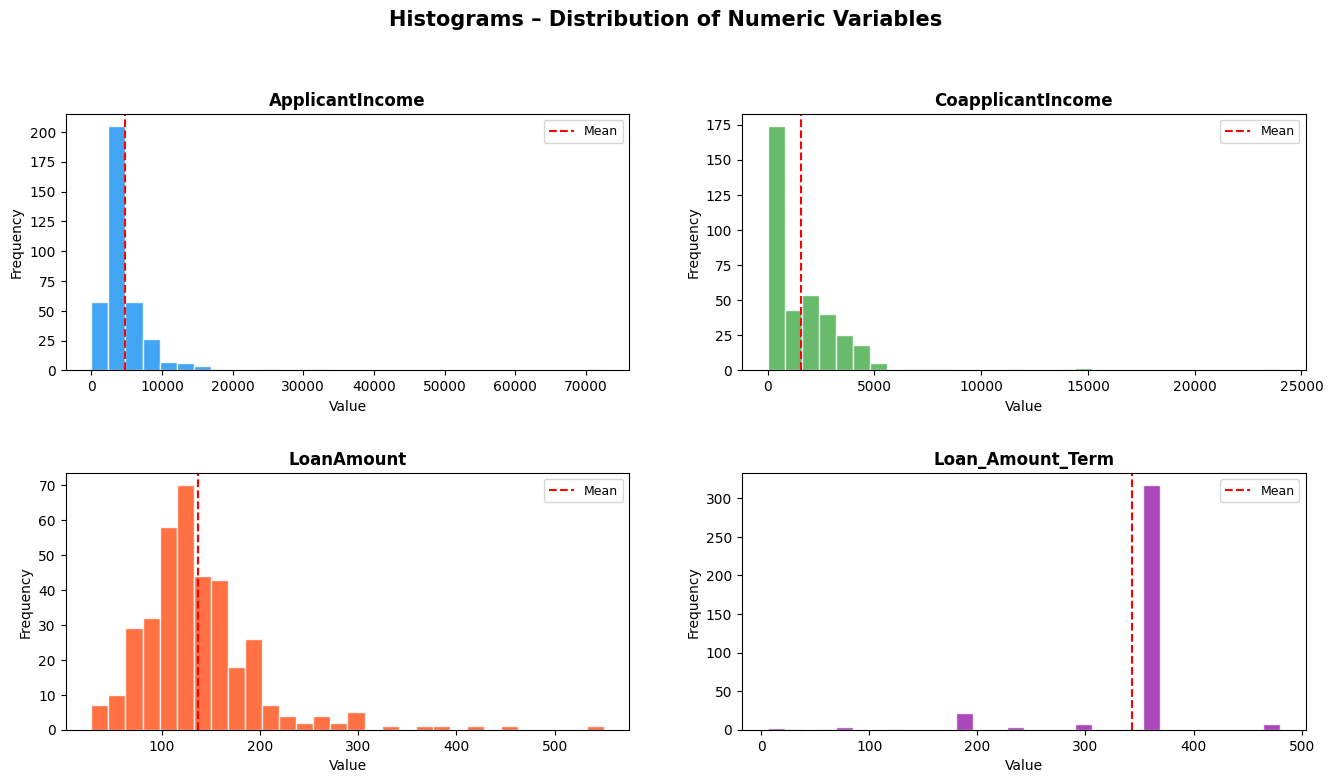

In [354]:
# ---- Histograms ----
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Histograms – Distribution of Numeric Variables', fontsize=15, fontweight='bold', y=1.01)

num_vars = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
colors   = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for ax, col, color in zip(axes.flat, num_vars, colors):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.legend(fontsize=9)

plt.subplots_adjust(wspace=(0.2), hspace=(0.4))
plt.savefig('hist_numeric.png', bbox_inches='tight')
plt.show()

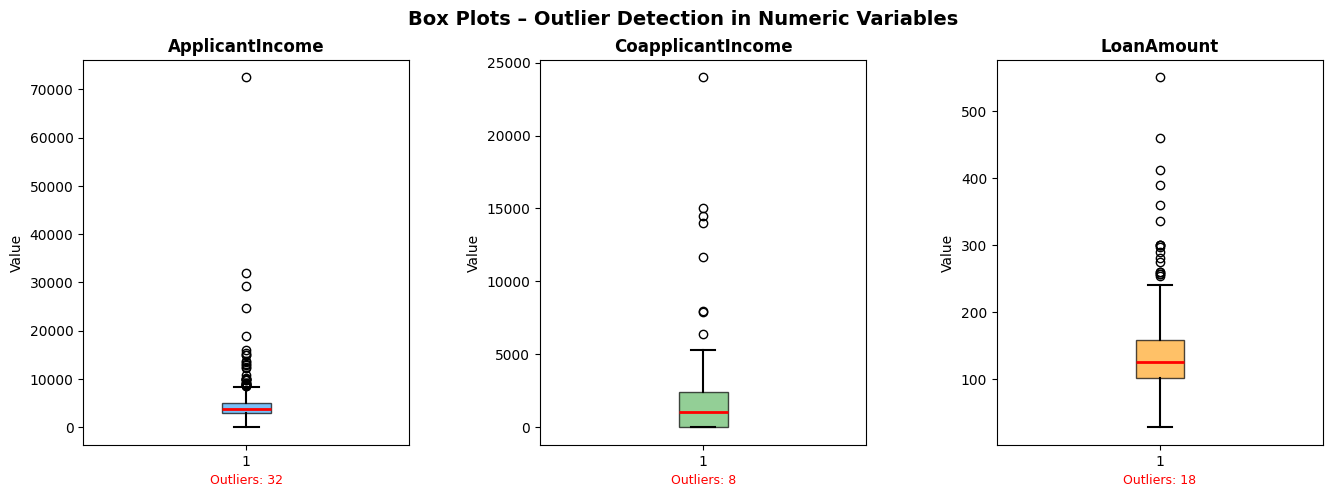

In [355]:
# ---- Box Plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Box Plots – Outlier Detection in Numeric Variables', fontsize=14, fontweight='bold')

box_vars  = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
box_colors = ['#42A5F5', '#66BB6A', '#FFA726']

for ax, col, color in zip(axes, box_vars, box_colors):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)][col].count()
    ax.set_xlabel("Outliers: " + str(outliers), fontsize=9, color='red')

plt.subplots_adjust(wspace=0.4)
plt.savefig('boxplot_numeric.png', bbox_inches='tight')
plt.show()

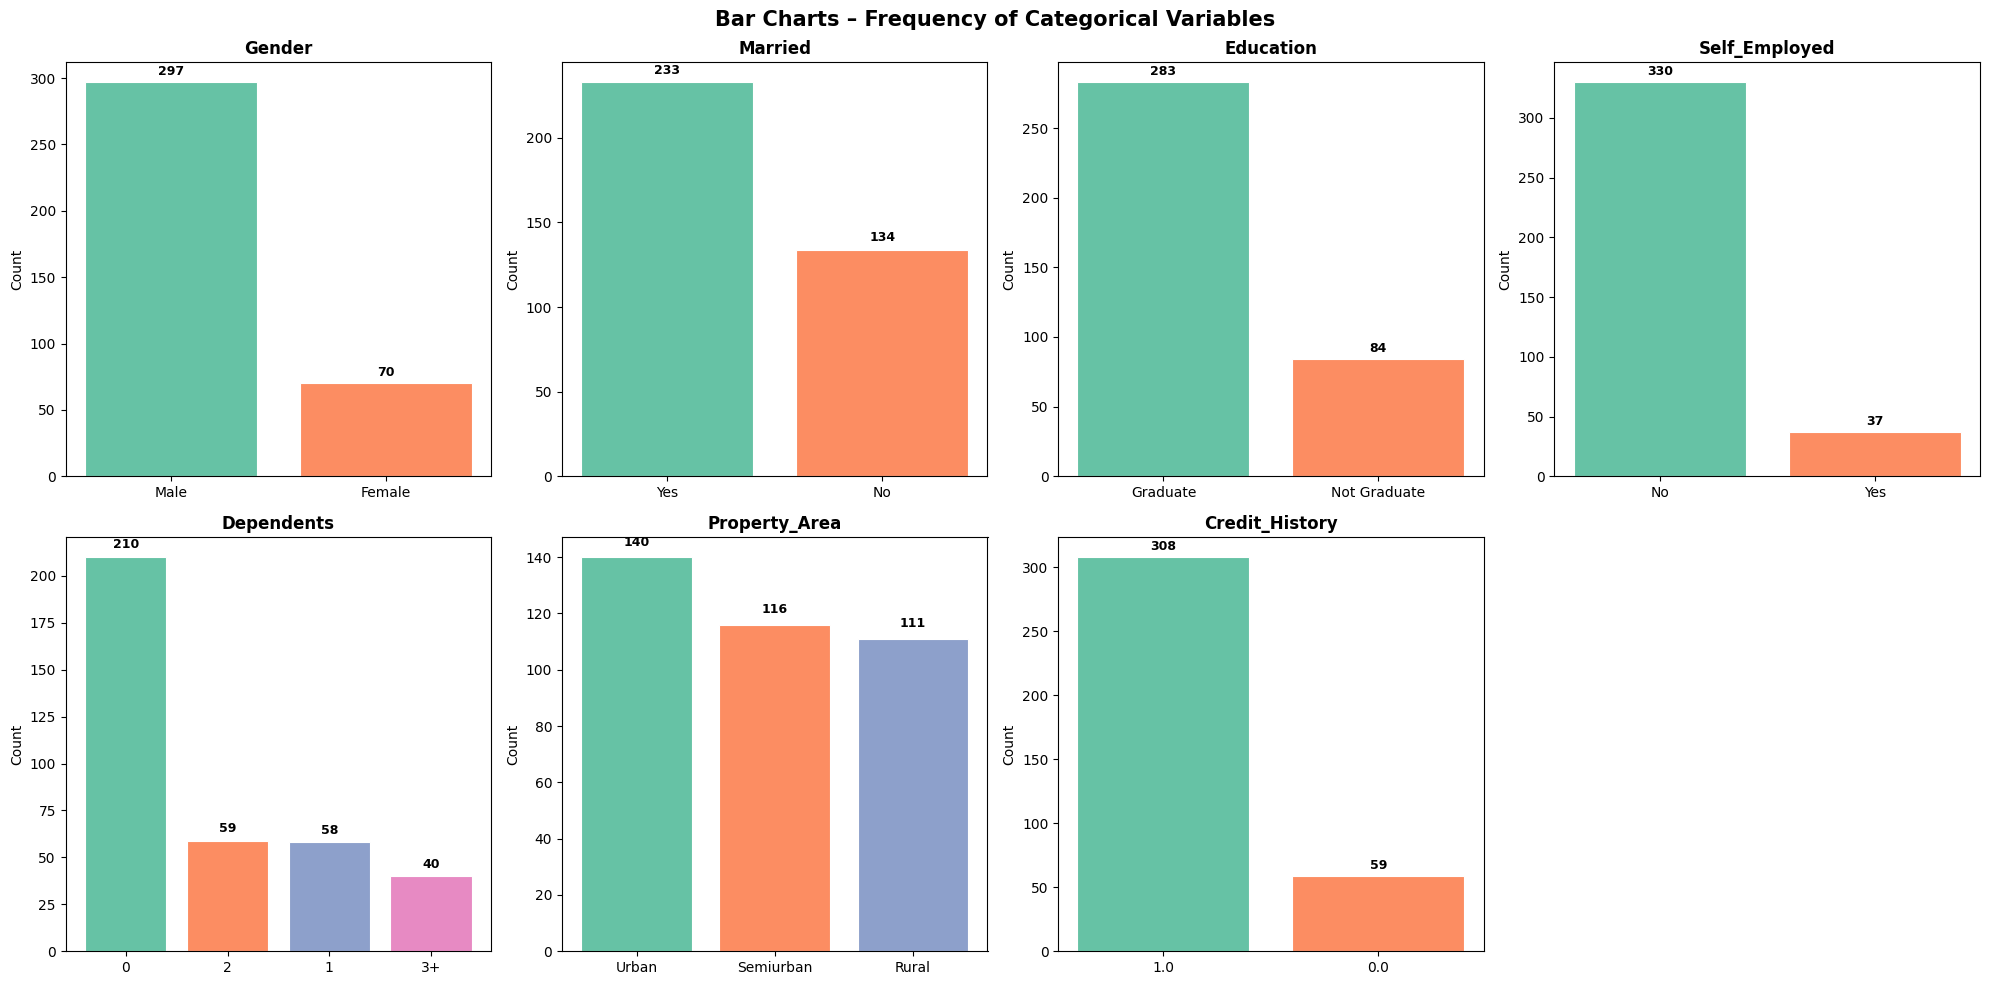

In [356]:
# ---- Bar Charts (Categorical) ----
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed',
            'Dependents', 'Property_Area', 'Credit_History']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Bar Charts – Frequency of Categorical Variables', fontsize=15, fontweight='bold')
palette = sns.color_palette("Set2", 6)

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=palette[:len(counts)], edgecolor='white', linewidth=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

axes.flat[-1].set_visible(False)   # hide unused 8th subplot
plt.tight_layout()
plt.savefig('barchart_categorical.png', bbox_inches='tight')
plt.show()

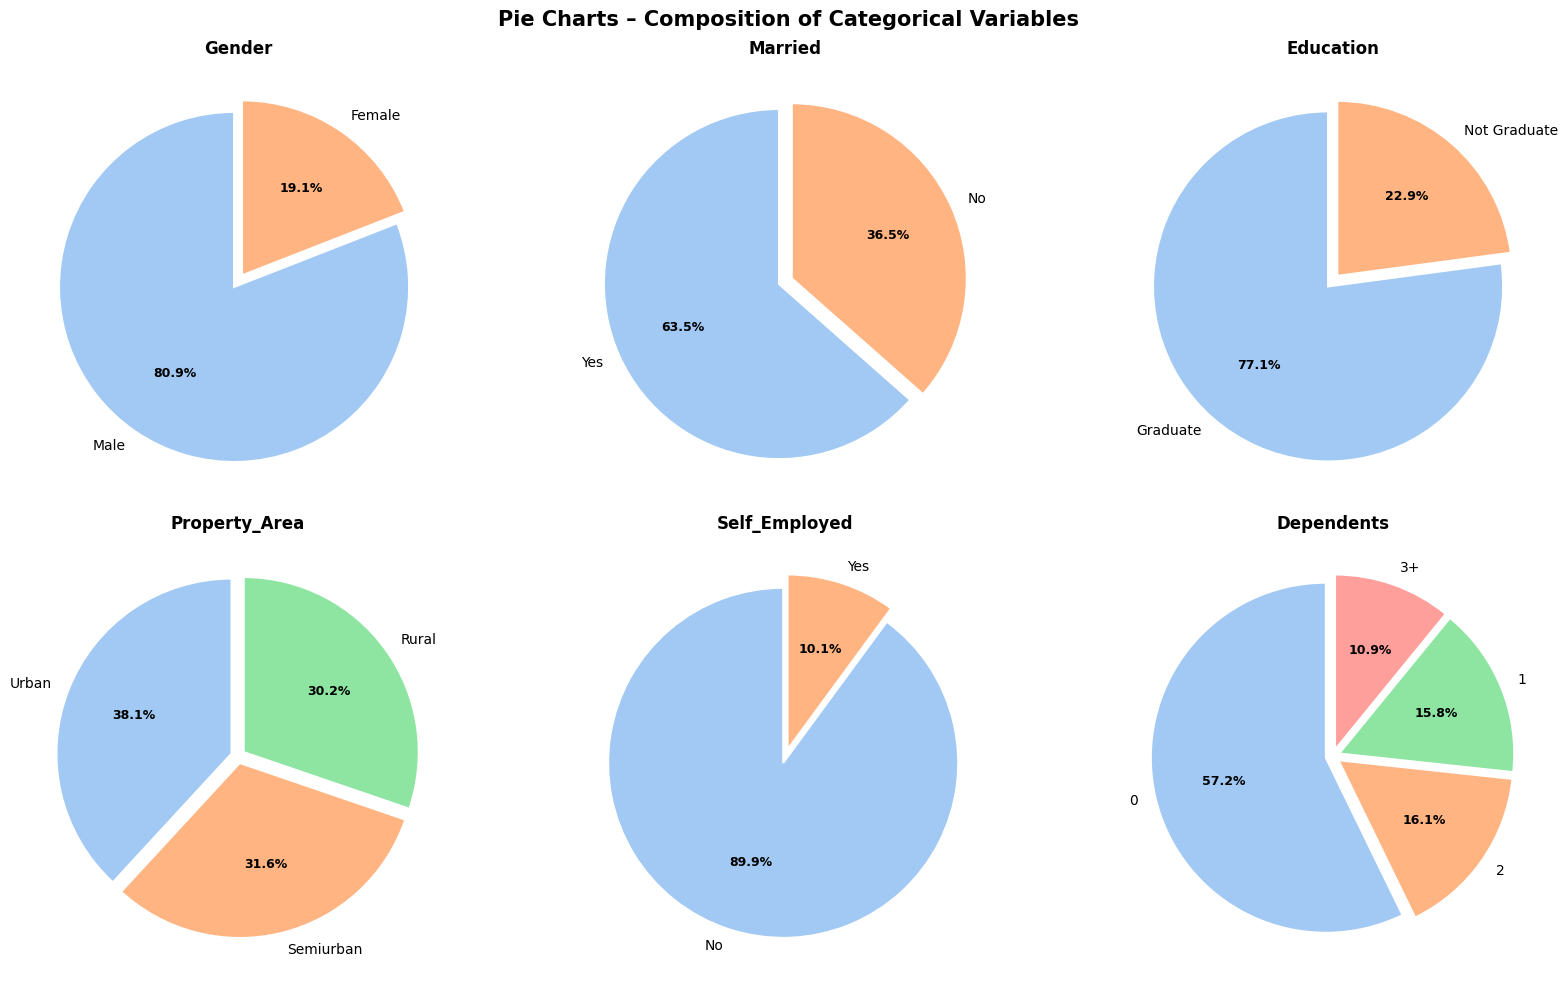

In [357]:
# ---- Pie Charts (Categorical) ----
pie_cols = ['Gender', 'Married', 'Education', 'Property_Area', 'Self_Employed', 'Dependents']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Pie Charts – Composition of Categorical Variables', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flat, pie_cols):
    counts = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        explode=[0.04] * len(counts),
        startangle=90,
        colors=sns.color_palette("pastel", len(counts)),
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')
    ax.set_title(col, fontweight='bold')

plt.tight_layout()
plt.savefig('piechart_categorical.png', bbox_inches='tight')
plt.show()

## 2.2 BIVARIATE ANALYSIS

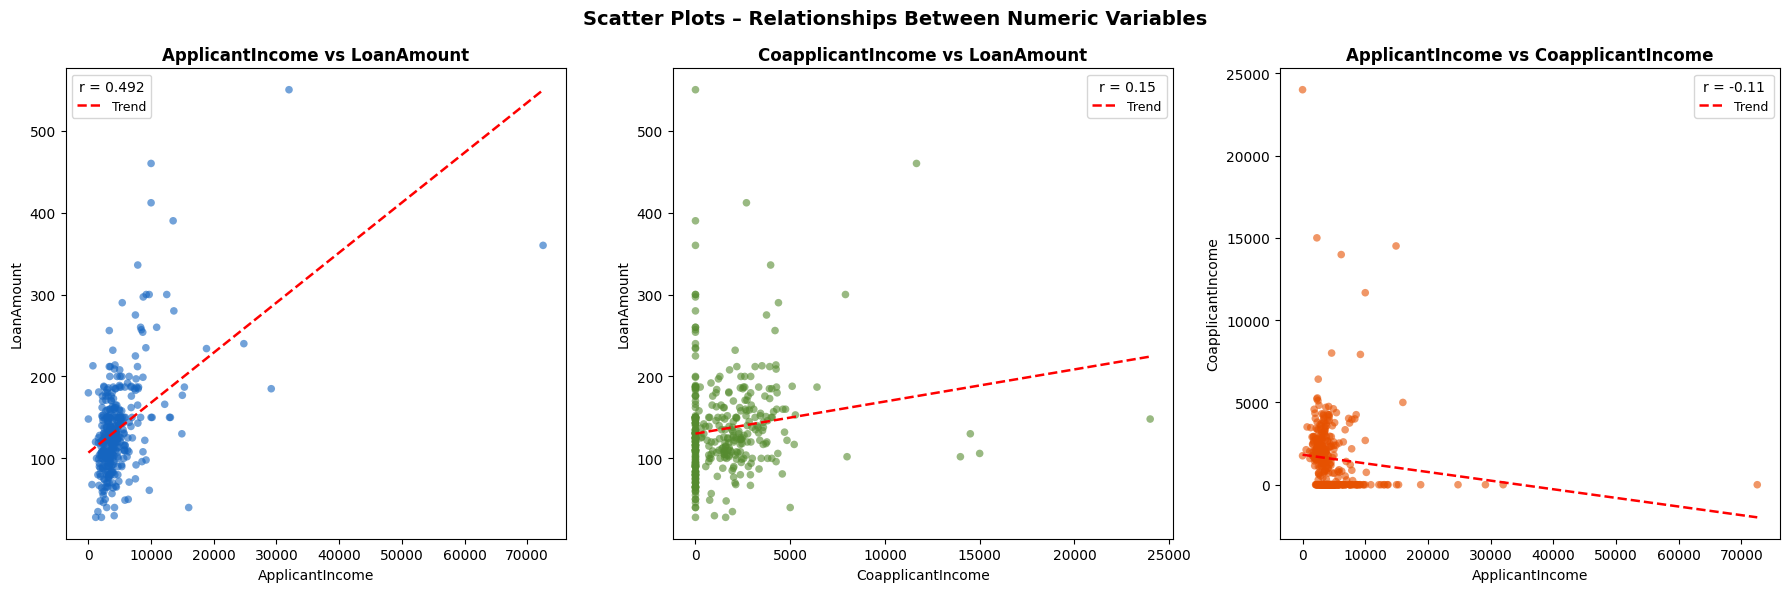

In [358]:
# ---- Scatter Plots ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scatter Plots – Relationships Between Numeric Variables', fontsize=14, fontweight='bold')

scatter_pairs = [
    ('ApplicantIncome', 'LoanAmount'),
    ('CoapplicantIncome', 'LoanAmount'),
    ('ApplicantIncome', 'CoapplicantIncome')
]
sc_colors = ['#1565C0', '#558B2F', '#E65100']

for ax, (x, y), c in zip(axes, scatter_pairs, sc_colors):
    ax.scatter(df[x], df[y], alpha=0.6, color=c, edgecolors='none', s=30)
    # trend line
    m, b = np.polyfit(df[x], df[y], 1)
    x_line = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.8, linestyle='--', label='Trend')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(x + " vs " + y, fontweight='bold')
    corr = df[x].corr(df[y])
    ax.legend(title="r = " + str(round(corr, 3)), fontsize=9)

plt.tight_layout()
plt.savefig('scatterplot_bivariate.png', bbox_inches='tight')
plt.show()

enerating pair plot...


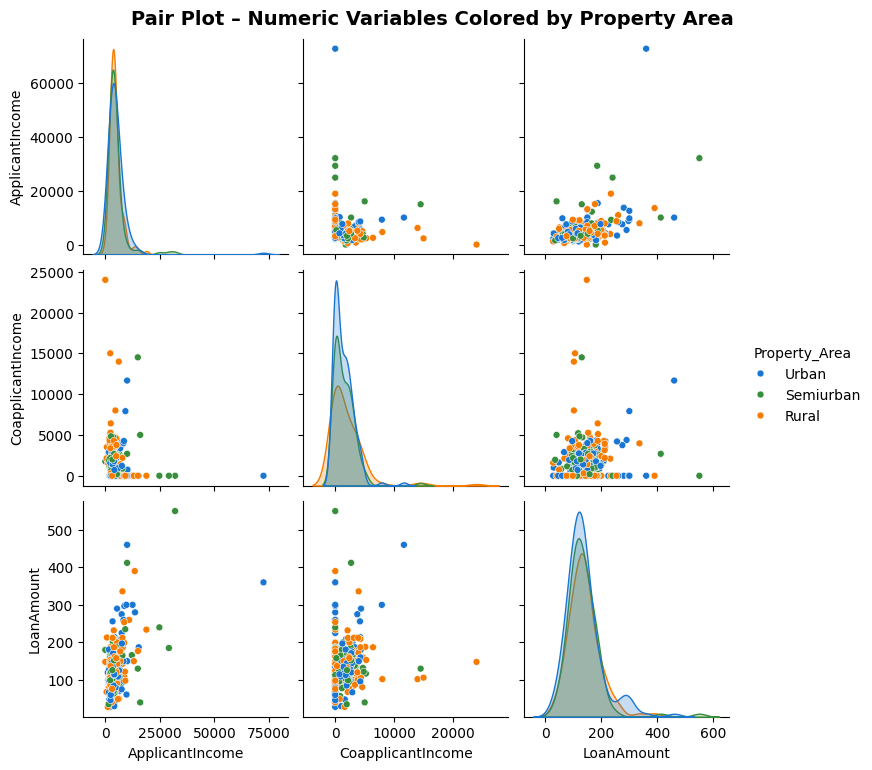

In [359]:
# ---- Pair Plot ----

print("enerating pair plot...")
pair_df   = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Property_Area']].copy()
pair_plot = sns.pairplot(pair_df, hue='Property_Area',
                         palette={'Urban': '#1976D2', 'Semiurban': '#388E3C', 'Rural': '#F57C00'},
                         plot_kws=dict(alpha=1, s=25),
                         diag_kind='kde')
pair_plot.fig.suptitle('Pair Plot – Numeric Variables Colored by Property Area',
                       y=1.02, fontsize=14, fontweight='bold')

plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

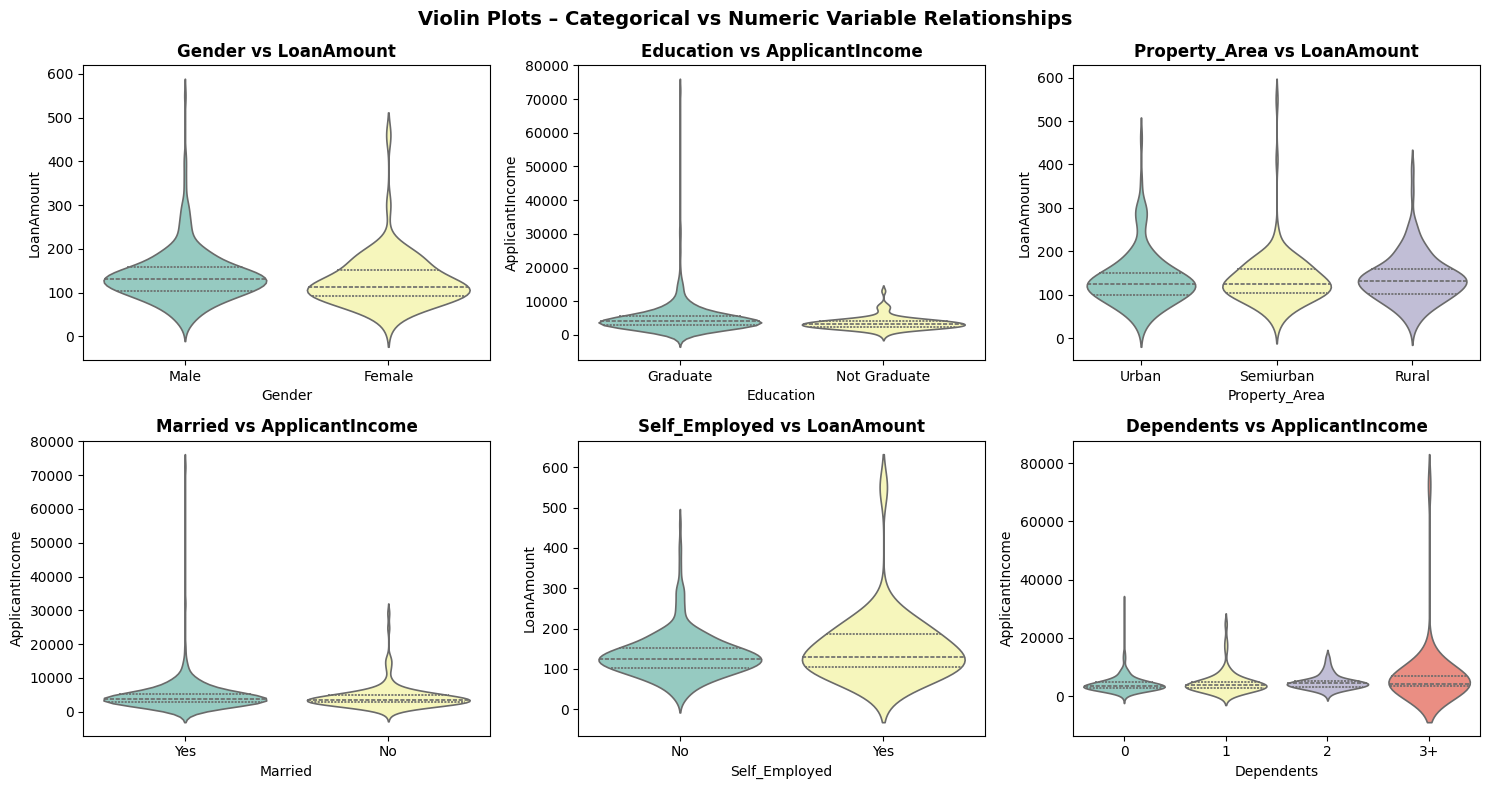

In [360]:
# ---- Violin Plots (Categorical vs Numeric) ----

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Violin Plots – Categorical vs Numeric Variable Relationships', fontsize=14, fontweight='bold')

violin_pairs = [
    ('Gender',        'LoanAmount'),
    ('Education',     'ApplicantIncome'),
    ('Property_Area', 'LoanAmount'),
    ('Married',       'ApplicantIncome'),
    ('Self_Employed', 'LoanAmount'),
    ('Dependents',    'ApplicantIncome')]   # replaces Loan_Status

for ax, (cat, num) in zip(axes.flat, violin_pairs):
    sns.violinplot(data=df, x=cat, y=num, ax=ax, hue=cat,
                   palette='Set3', inner='quartile', linewidth=1.2, legend=False)
    ax.set_title(cat + " vs " + num, fontweight='bold')
    ax.set_xlabel(cat)
    ax.set_ylabel(num)

plt.tight_layout()
plt.savefig('violin_cat_num.png', bbox_inches='tight')
plt.show()

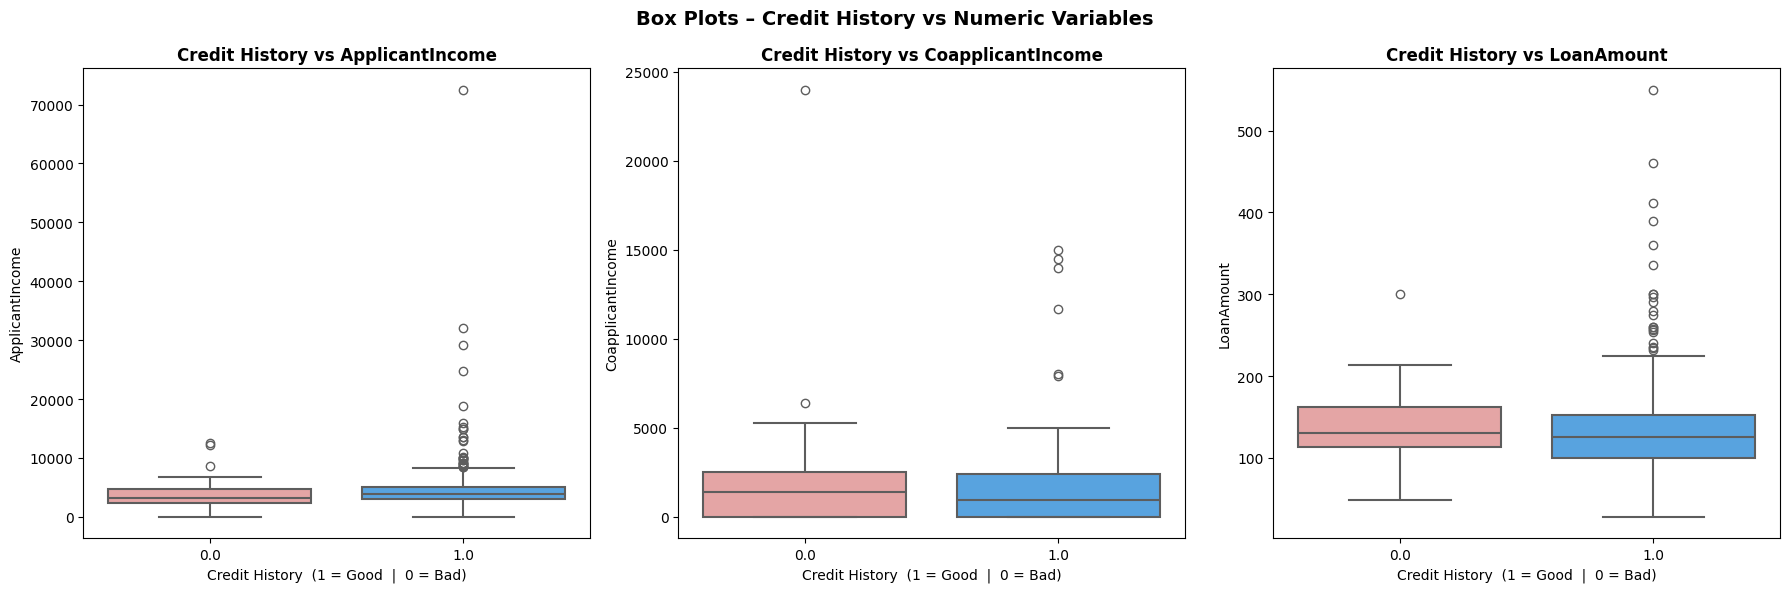

In [361]:
# ---- Box Plots: Credit_History vs Numeric  ----

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots – Credit History vs Numeric Variables', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']):
    sns.boxplot(data=df, x='Credit_History', y=col, ax=ax, hue='Credit_History',
                palette={1.0: '#42A5F5', 0.0: '#EF9A9A'}, linewidth=1.5, legend=False)
    ax.set_title("Credit History vs " + col, fontweight='bold')
    ax.set_xlabel('Credit History  (1 = Good  |  0 = Bad)')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplot_credithistory_vs_numeric.png', bbox_inches='tight')
plt.show()

## 2.3 MULTIVARIATE ANALYSIS

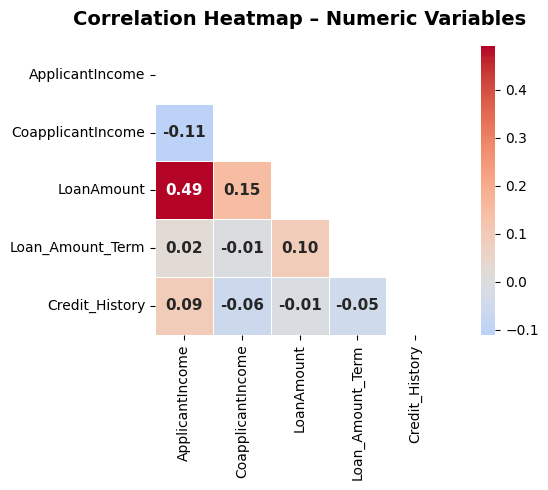

In [362]:
# ---- Correlation Heatmap ----
corr_df = df[numeric_cols].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='white',
            square=True,
            ax=ax,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_title('Correlation Heatmap – Numeric Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [363]:
# Top Correlation Analysis perform
print("Top Correlations (absolute value):")
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(10).round(3).to_string())

Top Correlations (absolute value):
LoanAmount         ApplicantIncome      0.492
CoapplicantIncome  LoanAmount           0.150
ApplicantIncome    CoapplicantIncome   -0.110
LoanAmount         Loan_Amount_Term     0.095
ApplicantIncome    Credit_History       0.095
Credit_History     CoapplicantIncome   -0.058
                   Loan_Amount_Term    -0.048
Loan_Amount_Term   ApplicantIncome      0.023
Credit_History     LoanAmount          -0.014
CoapplicantIncome  Loan_Amount_Term    -0.009


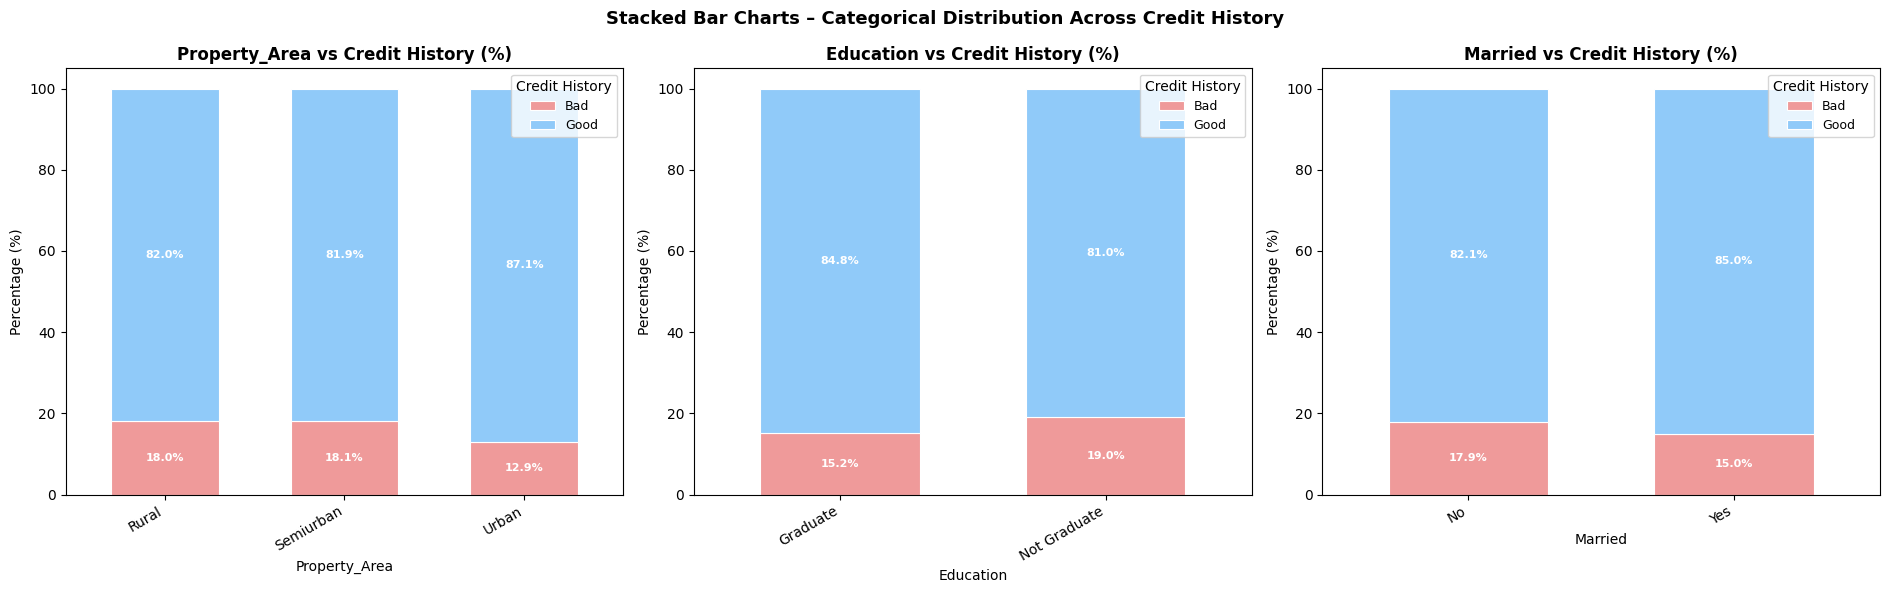

In [364]:
# ---- Stacked Bar Charts ----

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Stacked Bar Charts – Categorical Distribution Across Credit History',
             fontsize=13, fontweight='bold')

stacked_cats = ['Property_Area', 'Education', 'Married']

for ax, cat in zip(axes, stacked_cats):
    cross_tab = pd.crosstab(df[cat], df['Credit_History'].map({1.0: 'Good', 0.0: 'Bad'}))
    for col in ['Bad', 'Good']:
        if col not in cross_tab.columns:
            cross_tab[col] = 0
    cross_tab     = cross_tab[['Bad', 'Good']]
    cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    cross_tab_pct.plot(kind='bar', stacked=True, ax=ax,
                       color=['#EF9A9A', '#90CAF9'], edgecolor='white',
                       linewidth=0.8, width=0.6)
    ax.set_title(cat + " vs Credit History (%)", fontweight='bold')
    ax.set_xlabel(cat)
    ax.set_ylabel('Percentage (%)')
    ax.legend(title='Credit History', loc='upper right', fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center',
                     fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('stacked_bar_credit_history.png', bbox_inches='tight')
plt.show()

In [365]:
# ---- Plotly Interactive Scatter ----
fig_px = px.scatter(df, x='ApplicantIncome', y='LoanAmount',
    color='Property_Area', symbol='Education', size='CoapplicantIncome',
    hover_data=['Gender', 'Married', 'Credit_History', 'Dependents'],
    color_discrete_map={'Urban': '#1565C0', 'Semiurban': '#2E7D32', 'Rural': '#E65100'},
    title='Interactive: Applicant Income vs Loan Amount (colored by Property Area)',
    labels={'ApplicantIncome': 'Applicant Income', 'LoanAmount': 'Loan Amount'})
fig_px.update_layout(plot_bgcolor='#F8F9FA', paper_bgcolor='#FFFFFF',
                     font=dict(size=10), legend_title_text='Property Area')
fig_px.show()

## SUMMARY OF FINDINGS

In [366]:
good_credit_pct  = (df['Credit_History'] == 1.0).mean() * 100
grad_avg_income  = df[df['Education'] == 'Graduate']['ApplicantIncome'].mean()
non_grad_avg     = df[df['Education'] == 'Not Graduate']['ApplicantIncome'].mean()
top_area         = df['Property_Area'].value_counts().idxmax()
married_pct      = (df['Married'] == 'Yes').mean() * 100

print("  Total Records                     :", len(df))
print("  Applicants with Good Credit       :", round(good_credit_pct, 1), "%")
print("  Avg Income – Graduates            :", int(grad_avg_income))
print("  Avg Income – Non-Graduates        :", int(non_grad_avg))
print("  Most Common Property Area         :", top_area)
print("  Married Applicants                :", round(married_pct, 1), "%")
print("  Median Loan Amount (thousands)    :", df['LoanAmount'].median())
print("  Median Applicant Income           :", int(df['ApplicantIncome'].median()))
print("  Strongest Numeric Correlation     :", corr_pairs.index[0])

  Total Records                     : 367
  Applicants with Good Credit       : 83.9 %
  Avg Income – Graduates            : 5169
  Avg Income – Non-Graduates        : 3578
  Most Common Property Area         : Urban
  Married Applicants                : 63.5 %
  Median Loan Amount (thousands)    : 126.0
  Median Applicant Income           : 3786
  Strongest Numeric Correlation     : ('LoanAmount', 'ApplicantIncome')


# ______Code Executed Successfully.